In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = joblib.load(
    r'D:\# coding\PYTHON\Society Projects\Team task\cleaned_dataset.pkl')
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
0,0,0,0,0,1,1,1,1,0,1,...,9,0,6,0,0.0,0.0,0.0,0.0,2,1
1,2,0,0,0,1,1,1,0,1,1,...,6,0,5,12,0.0,0.0,0.0,0.0,2,0
2,3,1,0,0,0,0,0,0,0,0,...,7,1,0,21,1.0,0.0,0.0,0.0,1,1
5,3,0,0,0,1,0,1,1,0,0,...,5,1,3,15,0.0,1.0,0.0,0.0,1,0
6,1,1,0,0,0,0,0,0,0,0,...,6,3,0,6,0.0,0.0,0.0,0.0,1,3


In [3]:
df.columns

Index(['experience_years', 'python', 'java', 'c_cpp', 'javascript',
       'typescript', 'html_css', 'react', 'angular_vue', 'nodejs',
       'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb', 'postgresql',
       'pandas_numpy', 'scikit_learn', 'deep_learning', 'pytorch_tensorflow',
       'nlp', 'computer_vision', 'docker', 'kubernetes', 'git', 'linux', 'aws',
       'azure_gcp', 'ci_cd', 'terraform', 'cybersecurity_basics',
       'penetration_testing', 'flutter_react_native', 'target_career',
       'total_skills', 'ml_skill_count', 'web_skill_count',
       'experience_skill_score', 'education_level_B.Tech / B.E.',
       'education_level_BCA', 'education_level_M.Tech / MCA',
       'education_level_Self-Taught', 'programming_score', 'data_skill_score'],
      dtype='object')

In [4]:
x = df.iloc[:,1:33]
print("Number of features:", x.shape[1])
print("Number of students:", x.shape[0])

Number of features: 32
Number of students: 1399


In [5]:
x.columns

Index(['python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css',
       'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql',
       'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn',
       'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision',
       'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd',
       'terraform', 'cybersecurity_basics', 'penetration_testing',
       'flutter_react_native'],
      dtype='object')

In [6]:
scaler = joblib.load(
    r'D:\# coding\PYTHON\Society Projects\Team task\standard_scaler.pkl')

In [7]:
x_scaled = scaler.transform(x)

In [8]:
x_scaled.shape

(1399, 32)

In [9]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

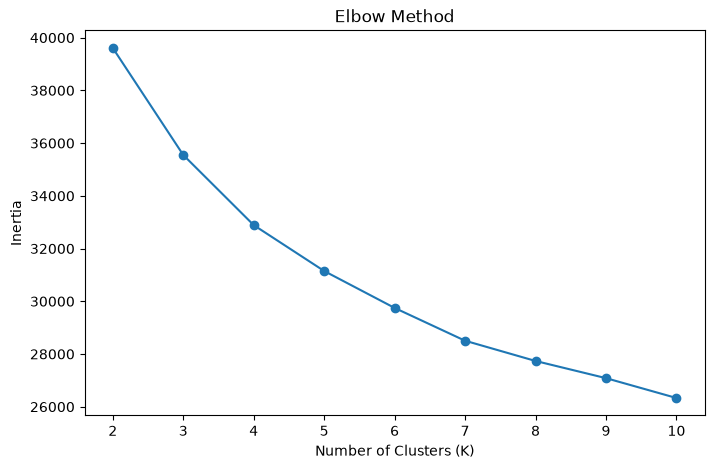

In [10]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),inertia,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [11]:
silhouette_scores = []
for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)    
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)    
    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.1331799848423969
K = 3 Silhouette Score = 0.13785207302256064
K = 4 Silhouette Score = 0.13749382684944944
K = 5 Silhouette Score = 0.14230996091445422
K = 6 Silhouette Score = 0.1457236274819807
K = 7 Silhouette Score = 0.14595229731170703
K = 8 Silhouette Score = 0.1323406022874064
K = 9 Silhouette Score = 0.12943439914875365
K = 10 Silhouette Score = 0.13286176673262828


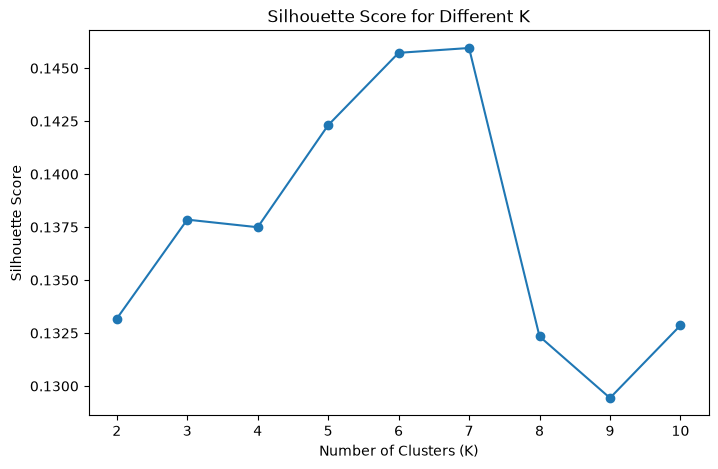

In [12]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),silhouette_scores,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.show()

In [13]:
optimal_k = 7

In [14]:
kmeans = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)

cluster_labels = kmeans.fit_predict(x_scaled)

In [15]:
df['cluster'] = cluster_labels
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score,cluster
0,0,0,0,0,1,1,1,1,0,1,...,0,6,0,0.0,0.0,0.0,0.0,2,1,6
1,2,0,0,0,1,1,1,0,1,1,...,0,5,12,0.0,0.0,0.0,0.0,2,0,6
2,3,1,0,0,0,0,0,0,0,0,...,1,0,21,1.0,0.0,0.0,0.0,1,1,2
5,3,0,0,0,1,0,1,1,0,0,...,1,3,15,0.0,1.0,0.0,0.0,1,0,6
6,1,1,0,0,0,0,0,0,0,0,...,3,0,6,0.0,0.0,0.0,0.0,1,3,3


In [16]:
print(df['cluster'].value_counts().sort_index())

cluster
0    121
1    282
2    264
3    307
4    109
5    123
6    193
Name: count, dtype: int64


In [17]:
pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(x_scaled)

In [18]:
print(x_pca_2d.shape)

(1399, 2)


In [19]:
pca_df = pd.DataFrame(x_pca_2d,columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
pca_df.head()

,PC1,PC2,cluster
0,4.729860,1.254357,6
1,4.681148,1.279763,6
2,-0.496974,-2.706923,2
3,2.874930,1.738316,6
4,-1.610448,0.476147,3


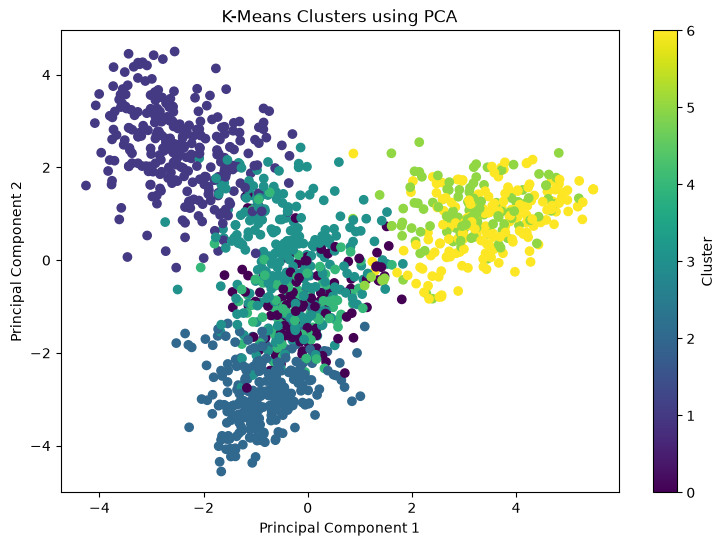

In [20]:
plt.figure(figsize=(9,6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")
plt.colorbar(label="Cluster")
plt.show()

In [25]:
print(pca_2d.explained_variance_ratio_.sum())

0.25592138542628534


In [26]:

profile = df.groupby('cluster')[x.columns].mean()


In [27]:
profile

,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,fastapi_flask,...,kubernetes,git,linux,aws,azure_gcp,ci_cd,terraform,cybersecurity_basics,penetration_testing,flutter_react_native
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.867769,0.834711,0.123967,0.049587,0.198347,0.033058,0.016529,0.074380,0.446281,0.834711,...,0.148760,0.818182,0.537190,0.561983,0.082645,0.462810,0.066116,0.049587,0.057851,0.033058
1,0.875887,0.088652,0.184397,0.028369,0.035461,0.046099,0.024823,0.031915,0.035461,0.485816,...,0.117021,0.769504,0.404255,0.492908,0.031915,0.223404,0.046099,0.039007,0.046099,0.046099
2,0.583333,0.037879,0.045455,0.049242,0.049242,0.045455,0.041667,0.041667,0.079545,0.132576,...,0.784091,0.507576,0.806818,0.791667,0.693182,0.625000,0.795455,0.268939,0.034091,0.041667
3,0.745928,0.026059,0.081433,0.032573,0.035831,0.061889,0.065147,0.032573,0.078176,0.130293,...,0.032573,0.573290,0.446254,0.306189,0.055375,0.123779,0.058632,0.078176,0.048860,0.035831
4,0.834862,0.229358,0.238532,0.055046,0.064220,0.036697,0.055046,0.036697,0.036697,0.027523,...,0.064220,0.853211,0.788991,0.376147,0.073394,0.201835,0.073394,0.770642,0.853211,0.036697
5,0.121951,0.430894,0.032520,0.804878,0.845528,0.186992,0.178862,0.032520,0.512195,0.439024,...,0.040650,0.869919,0.056911,0.040650,0.048780,0.065041,0.024390,0.048780,0.024390,0.853659
6,0.243523,0.062176,0.036269,0.834197,0.683938,0.829016,0.849741,0.305699,0.559585,0.243523,...,0.062176,0.896373,0.176166,0.077720,0.062176,0.113990,0.041451,0.046632,0.062176,0.005181


In [22]:
joblib.dump(kmeans,r'D:\# coding\PYTHON\Society Projects\Team task\kmeans_model.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\kmeans_model.pkl']

In [23]:
joblib.dump(pca_2d,r'D:\# coding\PYTHON\Society Projects\Team task\pca_2d.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\pca_2d.pkl']